In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("Bengaluru_House_Data.csv")

In [ ]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.shape

(13320, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df['location'].nunique()

1305

In [ ]:
df['location']=df['location'].fillna(df['location'].mode()[0])

In [ ]:
df['size']=df['size'].fillna(df['size'].mode()[0])

In [ ]:
df.drop('society',axis=1,inplace=True)

In [ ]:
df['bath']=df['bath'].fillna(df['bath'].median())

In [ ]:
df['balcony']=df['balcony'].fillna(df['balcony'].median())

In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [ ]:
df['bath'].describe()

,bath
count,13320.000000
mean,2.688814
std,1.338754
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,40.000000


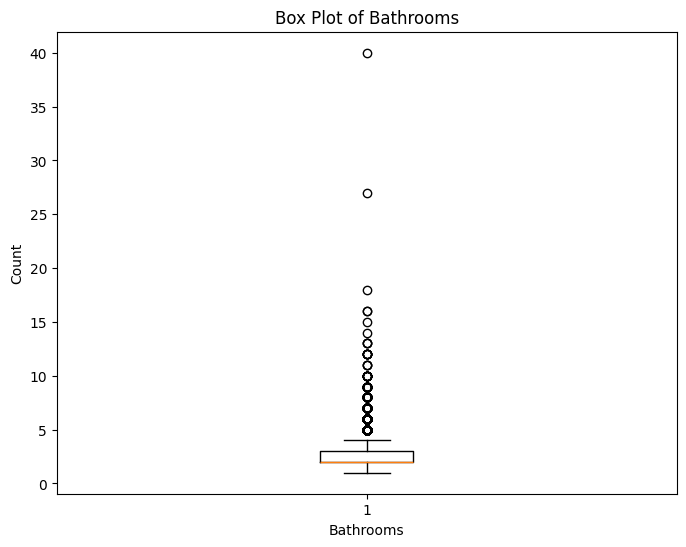

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(df['bath'].dropna())
plt.title("Box Plot of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.show()

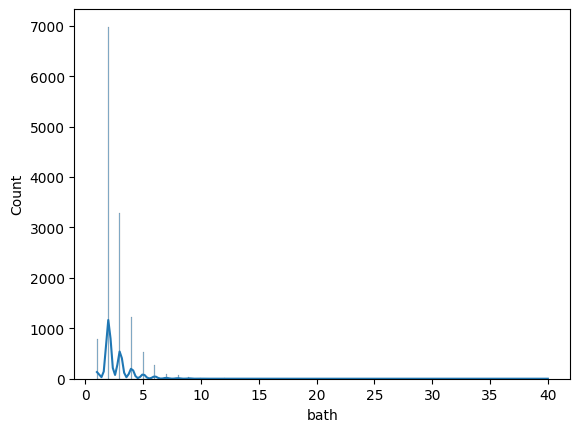

In [ ]:
import seaborn as sns

sns.histplot(df['bath'], kde=True)
plt.show()

In [ ]:
df['bhk']=df['size'].str.split().str[0].astype(int)

In [ ]:
df[['size','bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [ ]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [ ]:
df['size'].value_counts()

,count
size,
2 BHK,5215
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [ ]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,2


In [ ]:
df.drop('size',axis=1,inplace=True)

In [ ]:
df['total_sqft'].value_counts()

,count
total_sqft,
1200,843
1100,221
1500,205
2400,196
600,180
...,...
2920,1
5665.84,1
1369,1


In [ ]:
def is_float(x):
  try:
    float(x)
    return True
  except:
    return False

In [ ]:
df[~df['total_sqft'].apply(is_float)]['total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch',
       '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800',
       '1160 - 1195', '1000Sq. Meter', '4000 - 5249', '1115 - 1130',
       '1100Sq. Yards', '520 - 645', '1000 - 1285', '3606 - 5091',
       '650 - 665', '633 - 666', '5.31Acres', '30Acres', '1445 - 1455',
       '884 - 1116', '850 - 1093', '1440 - 1884', '716Sq. Meter',
       '547.34 - 827.31', '580 - 650', '3425 - 3435', '1804 - 2273',
       '3630 - 3800', '660 - 670', '1500Sq. Meter', '620 - 933',
       '142.61Sq. Meter', '2695 - 2940', '2000 - 5634', '1574Sq. Yards',
       '3450 - 3472', '1250 - 1305', '670 - 980', '1005.03 - 1252.49',
       '1004 - 1204', '361.33Sq. Yards', '645 - 936', '2710 - 3360',
       '2249.81 - 4112.19', '3436 - 3643', '2830 - 2882', '596 - 804',
       '1255 - 1863', '1300 - 1405', '1

In [ ]:
def convert_sqft(x):
  tokens=x.split('-')

  if len(tokens)==2:
    return (float(tokens[0])+float(tokens[1]))/2

  try:
    return float(x)
  except:
    return None

In [ ]:
df['total_sqft']=df['total_sqft'].apply(convert_sqft)

In [ ]:
df['total_sqft'].isnull().sum()

np.int64(46)

In [ ]:
df = df.dropna(subset=['total_sqft'])

In [ ]:
df['total_sqft'].value_counts()

,count
total_sqft,
1200.0,843
1100.0,221
1500.0,206
2400.0,196
600.0,180
...,...
1916.0,1
4225.0,1
3734.0,1


In [ ]:
df.shape

(13274, 8)

In [ ]:
df['sqft_per_bhk']=df['total_sqft']/df['bhk']

In [ ]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.0
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.0
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,600.0


In [ ]:
df['sqft_per_bhk'].describe()

,sqft_per_bhk
count,13274.000000
mean,575.074878
std,388.205175
min,0.250000
25%,473.333333
50%,552.500000
75%,625.000000
max,26136.000000


In [ ]:
df.sort_values('sqft_per_bhk').head(20)

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,sqft_per_bhk
4086,Plot Area,Ready To Move,Sarjapur Road,1.0,4.0,2.0,120.0,4,0.250000
4972,Built-up Area,Ready To Move,Srirampuram,5.0,7.0,3.0,115.0,7,0.714286
349,Plot Area,18-Dec,Suragajakkanahalli,11.0,3.0,2.0,74.0,3,3.666667
1122,Built-up Area,Ready To Move,Grihalakshmi Layout,24.0,2.0,2.0,150.0,5,4.800000
1020,Carpet Area,Ready To Move,Weavers Colony,15.0,1.0,0.0,30.0,1,15.000000
11558,Plot Area,19-Oct,Whitefield,60.0,4.0,2.0,218.0,4,15.000000
5970,Plot Area,Ready To Move,Mysore Road,45.0,1.0,0.0,23.0,1,45.000000
4684,Plot Area,Ready To Move,Munnekollal,2400.0,40.0,0.0,660.0,43,55.813953
770,Plot Area,Ready To Move,Sector 3 HSR Layout,600.0,9.0,3.0,190.0,9,66.666667
11559,Plot Area,18-Apr,1Kasavanhalli,1200.0,18.0,2.0,200.0,18,66.666667


In [ ]:
df=df[df['sqft_per_bhk']>=300]

In [ ]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,sqft_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,650.0
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,507.0
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2,600.0


In [ ]:
df['location']=df['location'].apply(lambda x:x.strip())

In [ ]:
location_stats=df['location'].value_counts()

In [ ]:
location_stats_less_than_10 = location_stats[location_stats <= 10]
location_stats_less_than_10

,count
location,
Gunjur Palya,10
Laggere,10
1st Block Koramangala,10
Giri Nagar,10
Dodsworth Layout,10
...,...
Vasantapura main road,1
"Bidere Agarahara, Behind Safal market",1
Byappanahalli,1


In [ ]:
len(location_stats_less_than_10)

984

In [ ]:
df['location'] = df['location'].apply(
    lambda x: 'other' if x in location_stats_less_than_10 else x
)

In [ ]:
df['location'].value_counts()

,count
location,
other,2718
Whitefield,539
Sarjapur Road,395
Electronic City,295
Kanakpura Road,269
...,...
Narayanapura,11
Vasanthapura,11
Banashankari Stage VI,11


In [ ]:
df['location'].nunique()

223

In [ ]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [ ]:
df['price_per_sqft']

,price_per_sqft
0,3699.810606
1,4615.384615
2,4305.555556
3,6245.890861
4,4250.000000
...,...
13315,6689.834926
13316,11111.111111
13317,5258.545136
13318,10407.336319


In [ ]:
def remove_outliers(df):
  df_out=pd.DataFrame()
  for key,subdf in df.groupby('location'):
    m=np.mean(subdf.price_per_sqft)
    st=np.std(subdf.price_per_sqft)
    reduced_df=subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
    df_out=pd.concat([df_out,reduced_df],ignore_index=True)
  return df_out
df_out=remove_outliers(df)
df_out.shape

(10330, 10)

In [ ]:
df = remove_outliers(df)

In [ ]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):
        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)

            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < stats['mean']].index.values
                )

    return df.drop(exclude_indices, axis='index')

df = remove_bhk_outliers(df)

In [ ]:
df = remove_bhk_outliers(df)

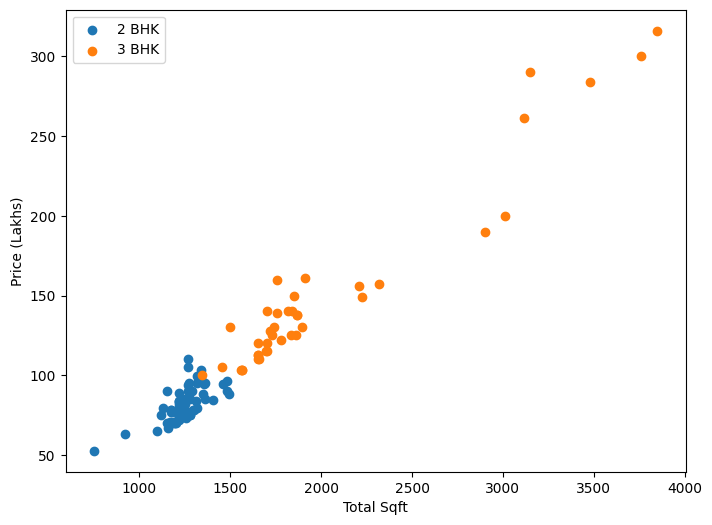

In [ ]:
import matplotlib.pyplot as plt

whitefield = df[df['location'] == 'Whitefield']

plt.figure(figsize=(8,6))

plt.scatter(
    whitefield[whitefield['bhk'] == 2]['total_sqft'],
    whitefield[whitefield['bhk'] == 2]['price'],
    label='2 BHK'
)

plt.scatter(
    whitefield[whitefield['bhk'] == 3]['total_sqft'],
    whitefield[whitefield['bhk'] == 3]['price'],
    label='3 BHK'
)

plt.xlabel("Total Sqft")
plt.ylabel("Price (Lakhs)")
plt.legend()
plt.show()

In [ ]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,sqft_per_bhk,price_per_sqft
1,Super built-up Area,Ready To Move,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3,625.000000,8906.666667
2,Built-up Area,Ready To Move,1st Phase JP Nagar,1500.0,5.0,2.0,85.0,5,300.000000,5666.666667
3,Super built-up Area,Ready To Move,1st Phase JP Nagar,2065.0,4.0,1.0,210.0,3,688.333333,10169.491525
5,Super built-up Area,Ready To Move,1st Phase JP Nagar,2059.0,3.0,2.0,225.0,3,686.333333,10927.634774
6,Super built-up Area,Ready To Move,1st Phase JP Nagar,1394.0,2.0,1.0,100.0,2,697.000000,7173.601148


In [ ]:
df = df.drop(['sqft_per_bhk', 'price_per_sqft'], axis=1)

In [ ]:
df.drop('availability', axis=1, inplace=True)

In [ ]:
df=pd.get_dummies(
    df,
    columns=['location','area_type'],
    drop_first=True
)

In [ ]:
X=df.drop('price',axis=1)
y=df['price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
models={
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "ElasticNet":ElasticNet()
}


In [ ]:
for name,model in models.items():
  model.fit(X_train_scaled,y_train)

  y_pred=model.predict(X_test_scaled)

  print(f"\n{name}")
  print("R2 Score :", r2_score(y_test, y_pred))
  print("MAE      :", mean_absolute_error(y_test, y_pred))
  print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))


LinearRegression
R2 Score : 0.7662699294551192
MAE      : 17.283123839993596
RMSE     : 39.679546165717625

Ridge
R2 Score : 0.766421666264484
MAE      : 17.278444061774376
RMSE     : 39.66666415782225

Lasso
R2 Score : 0.7590468495256235
MAE      : 19.10049558621041
RMSE     : 40.287999751327476

ElasticNet
R2 Score : 0.7976328740153837
MAE      : 20.687047523070078
RMSE     : 36.921503949948395


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

for name,model in models.items():
  pipe=Pipeline([
      ('scaler',StandardScaler()),
      ('model',model)
  ])
  scores=cross_val_score(
      pipe,
      X_train,
      y_train,
      cv=5,
      scoring='r2'
  )

  print("="*50)
  print(name)
  print("Scores",scores)
  print("Mean R2 ",scores.mean())

LinearRegression
Scores [0.85793709 0.82792163 0.8723139  0.84861314 0.8345563 ]
Mean R2  0.8482684114738428
Ridge
Scores [0.85795597 0.82794388 0.87234885 0.84872899 0.83445578]
Mean R2  0.8482866954998493
Lasso
Scores [0.84903058 0.82154058 0.86342114 0.84355202 0.82391987]
Mean R2  0.8402928388696889
ElasticNet
Scores [0.75900719 0.78262079 0.79623544 0.83315891 0.7020561 ]
Mean R2  0.7746156863818522


In [ ]:
scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')

print(scores)
print("Mean:", scores.mean())
print("Std :", scores.std())

[0.75900719 0.78262079 0.79623544 0.83315891 0.7020561 ]
Mean: 0.7746156863818522
Std : 0.04351395839210362


In [ ]:
print(df.columns)

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk',
       'location_2nd Phase Judicial Layout', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar',
       'location_8th Phase JP Nagar',
       ...
       'location_Whitefield', 'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_other', 'area_type_Carpet  Area',
       'area_type_Plot  Area', 'area_type_Super built-up  Area'],
      dtype='object', length=230)


In [ ]:
df.head()

,total_sqft,bath,balcony,price,bhk,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,...,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
1,1875.0,3.0,1.0,167.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1500.0,5.0,2.0,85.0,5,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2065.0,4.0,1.0,210.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,2059.0,3.0,2.0,225.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6,1394.0,2.0,1.0,100.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
print(X.columns.tolist())

['total_sqft', 'bath', 'balcony', 'bhk', 'location_2nd Phase Judicial Layout', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_9th Phase JP Nagar', 'location_AECS Layout', 'location_Abbigere', 'location_Akshaya Nagar', 'location_Ambalipura', 'location_Ambedkar Nagar', 'location_Amruthahalli', 'location_Anandapura', 'location_Ananth Nagar', 'location_Anekal', 'location_Anjanapura', 'location_Ardendale', 'location_Arekere', 'location_Attibele', 'location_BEML Layout', 'location_BTM 2nd Stage', 'location_BTM Layout', 'location_Babusapalaya', 'location_Badavala Nagar', 'location_Balagere', 'location_Banashankari', 'location_Banashankari Stage II', 'location_Banashankari Stage III', 'location_Banashankari Stage V', 'location_Banashankari Stage VI', 'location_Banaswadi', 'location_Bannerghatta', 'location_Bannerghatta Road', 'location_Basavangudi', 'location_Basaveshwara Nagar', 'location_Battarahalli', 'lo

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
models = {
    "Ridge": (
        Ridge(),
        {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
        }
    ),

    "Lasso": (
        Lasso(),
        {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
        }
    ),

    "ElasticNet": (
        ElasticNet(),
        {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
            "model__l1_ratio": [0.1,0.3,0.5,0.7,0.9]
        }
    )
}

In [ ]:
results = []

for name, (model, params) in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Best CV Score": grid.best_score_
    })

    print("="*60)
    print(name)
    print("Best Parameters :", grid.best_params_)
    print("Best CV Score :", grid.best_score_)

Ridge
Best Parameters : {'model__alpha': 100}
Best CV Score : 0.8487343817844962
Lasso
Best Parameters : {'model__alpha': 0.1}
Best CV Score : 0.8482794330047497
ElasticNet
Best Parameters : {'model__alpha': 0.1, 'model__l1_ratio': 0.9}
Best CV Score : 0.8486555927836366


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Best Parameters,Best CV Score
0,Ridge,{'model__alpha': 100},0.848734
1,Lasso,{'model__alpha': 0.1},0.848279
2,ElasticNet,"{'model__alpha': 0.1, 'model__l1_ratio': 0.9}",0.848656


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.1))   # Replace 0.1 with your best alpha
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=0.1))])

In [ ]:
import joblib

joblib.dump(final_model, "bangalore_house_price_model.pkl")

['bangalore_house_price_model.pkl']

In [ ]:
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']